<a href="https://colab.research.google.com/github/user127386/AI-ML/blob/user127386/zomato_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text(0.5, 1.0, 'x/2')

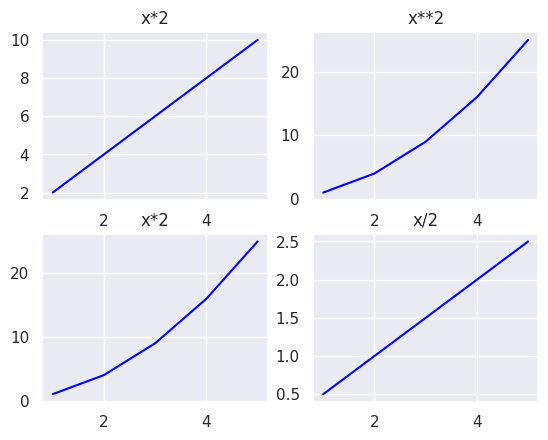

In [ ]:
x = np.array([1,2,3,4,5])
figure,axes = plt.subplots(2,2)
axes[0][0].plot(x,x*2,color = 'blue')
axes[0][0].set_title("x*2")
axes[0][1].plot(x,x**2,color = 'blue')
axes[0][1].set_title("x**2")
axes[1][0].plot(x,(-x)**2,color = 'blue')
axes[1][0].set_title("x*2")
axes[1][1].plot(x,x/2,color = 'blue')
axes[1][1].set_title("x/2")

In [ ]:
#Zomato Delivery Data Analysis Using Python
#It is mroe important customer preferencews and restaurant trends
#to make informed business decisions in food industry
#Do more restaurants provide online delivery compared to offline services?
#Which types of restaurant are most facoured by the general public?
#What price range do couples prefer for dining out?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_zomato = pd.read_csv("/content/Zomato-data- (1).csv")
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [ ]:
def handleRate(value):
  value = str(value).split('/')
  value = value[0]
  return float(value)
df_zomato['rate'] = df_zomato['rate'].apply(handleRate)
print(df_zomato.head(10))

                                              name online_order book_table  \
0                                            Jalsa          Yes        Yes   
1                                   Spice Elephant          Yes         No   
2                                  San Churro Cafe          Yes         No   
3                            Addhuri Udupi Bhojana           No         No   
4                                    Grand Village           No         No   
5                                  Timepass Dinner          Yes         No   
6  Rosewood International Hotel - Bar & Restaurant           No         No   
7                                           Onesta          Yes        Yes   
8                                   Penthouse Cafe          Yes         No   
9                                        Smacznego          Yes         No   

   rate  votes  approx_cost(for two people) listed_in(type)  
0   4.1    775                          800          Buffet  
1   4.1    787   

In [ ]:
df_zomato.describe().round(2)

,rate,votes,approx_cost(for two people)
count,148.00,148.00,148.00
mean,3.63,264.81,418.24
std,0.40,653.68,223.09
min,2.60,0.00,100.00
25%,3.30,6.75,200.00
50%,3.70,43.50,400.00
75%,3.90,221.75,600.00
max,4.60,4884.00,950.00


In [ ]:
df_zomato.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


Text(0.5, 0, 'Types Of Company')

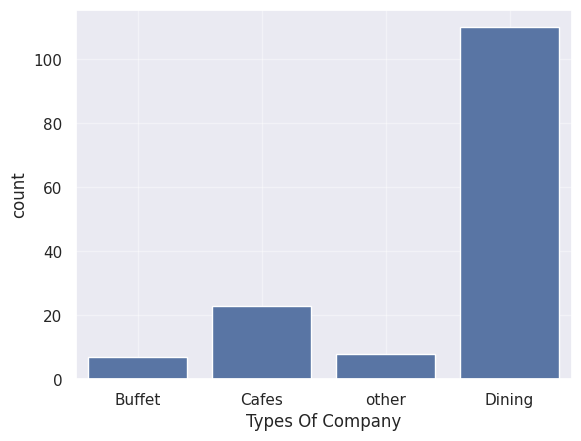

In [ ]:
#Let's see the listed_in(type)
sns.countplot(x=df_zomato["listed_in(type)"])
plt.grid(True, alpha= 0.4)
plt.xlabel("Types Of Company")

In [ ]:
#Conclusion: majority of restaurant fall into the dining category

Text(0.5, 1.0, 'Votes per restaurant')

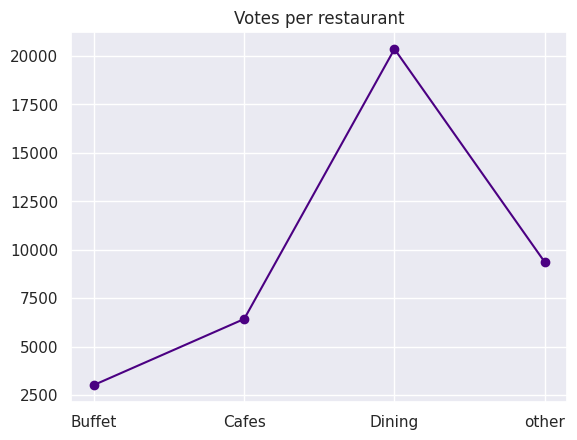

In [ ]:
#Votes by Restaurnat Type
grouped_data = df_zomato.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, color='indigo', marker='o')
plt.title("Votes per restaurant")

In [ ]:
#concllusion: Dining restaurant is more preferred by the prople

In [ ]:
#Identify the most voted Restaurant
#Find the restaurant with the highest number of votes
max_votes = df_zomato['votes'].max()
restaurant_with_max_votes = df_zomato.loc[df_zomato['votes'] == max_votes, 'name']
print(restaurant_with_max_votes)

38    Empire Restaurant
Name: name, dtype: object


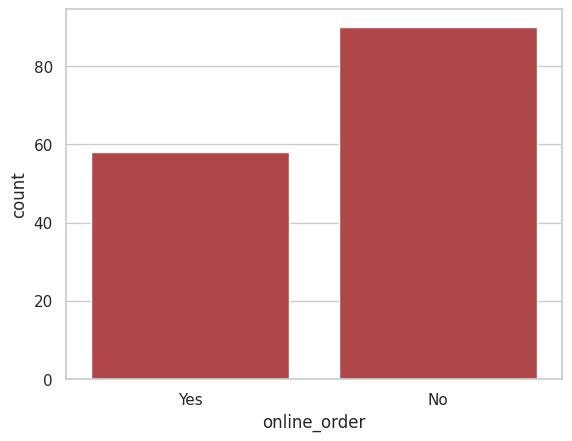

In [ ]:
#Step 6: Online order availability
#Exploring how many restaurant have online order and
# how many dont have the feature and plottiug it in the graph
sns.countplot(x=df_zomato['online_order'])
sns.set_theme(style='whitegrid', palette ='RdBu' )

In [ ]:
#concclusion: Online order is less then the offline order
#meaning many restaurant prefer offline order than online order

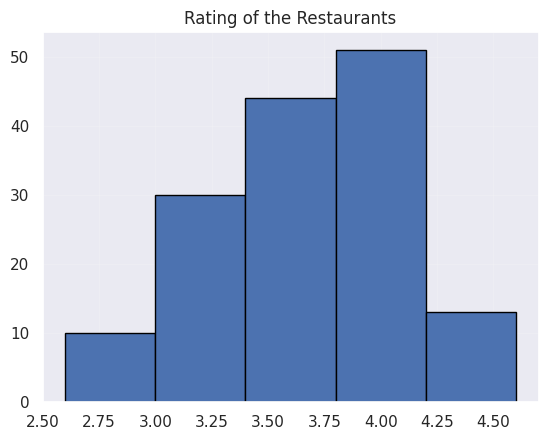

In [ ]:
#Step 7: Analyzing ratings
#Checking the distribution of ranting from the rate coloumn
plt.hist(df_zomato['rate'], bins =5,edgecolor ='black')
plt.title("Rating of the Restaurants")
plt.grid(True, alpha= 0.15)


In [ ]:
#Conclusion: Majority of the restaurant are rated between 3.5 to 4 star

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

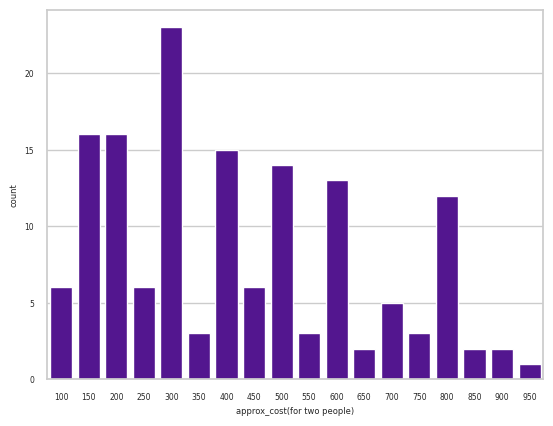

In [ ]:
#Step 8: Approximate Cost for two people booking the table
#To find prefered price range by couples
couple_data = df_zomato['approx_cost(for two people)']
sns.set_theme(font_scale=0.5, style='whitegrid', palette = 'plasma')
sns.countplot(x=couple_data )

In [ ]:
#Conclusion: most couples prefer restaurant with aprrox cost of 300

<Axes: xlabel='online_order', ylabel='rate'>

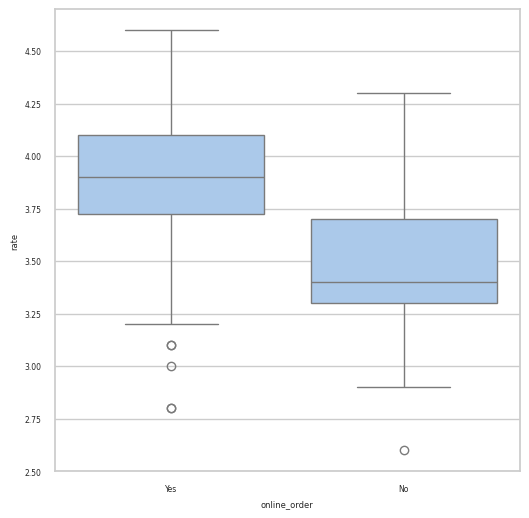

In [ ]:
#Step 10: Ratings Comparison(Online vs Offline)
#Compare ratings between restaurants that accept online orders and those that don't
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y='rate', data=df_zomato)

In [ ]:
#Conclusion: Online order featured restaurant have higher ratings compared to offline order

Text(0.5, 25.049999999999997, 'Offline / Online')

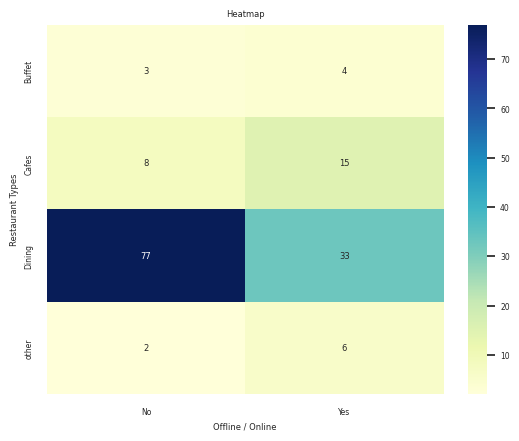

In [ ]:
#Order
pivot_table = df_zomato.pivot_table(index = 'listed_in(type)', columns='online_order',aggfunc = 'size')
sns.heatmap(pivot_table, cmap = 'YlGnBu', annot=True, fmt = 'd')
# annot shows number, cmap is the color of the boxes
plt.title('Heatmap')
plt.ylabel("Restaurant Types")
plt.xlabel("Offline / Online")

In [ ]:
#Conclusion: